Imbalanced Data

1-Oversampling:
                This technique balances the dataset by increasing the number of samples in the minority class. It can be done either by duplicating existing samples or by generating new synthetic data. As a result, it helps the model learn more effectively and reduces bias toward the majority class

2-SMOTE (Synthetic Minority Over-sampling Technique):
                                                      
                                                     SMOTE creates "smart" synthetic data points along the lines between original minority samples and their neighbors, instead of simple duplication.Advantages: It provides more diversity to the model and improves performance on the minority class.Disadvantages: It may create unrealistic synthetic points, does not handle class overlap, and carries a risk of overfitting.

3-Undersampling:
                
                 This technique balances the dataset by reducing the number of samples in the majority class.Methods: Includes Random Undersampling, which might lose important information, and Cluster-Based Undersampling, which preserves diversity within the majority class.Advantages: Results in a smaller dataset and faster training.Disadvantages: It may discard important data from the majority class.

4-Class Weights:
                Instead of changing the number of samples in the data (like in Oversampling or Undersampling), this technique modifies the learning algorithm itself to pay more attention to the minority class. It works by assigning a higher "weight" or "penalty" to the model when it misclassifies a minority class sample, forcing the model to learn its features more accurately to minimize the overall error cost.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

df = pd.read_csv(r"C:\Users\zbook g6\Uni_ML_Task\Uni_ML_Tasks\wisc_bc_data.csv")


In [3]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


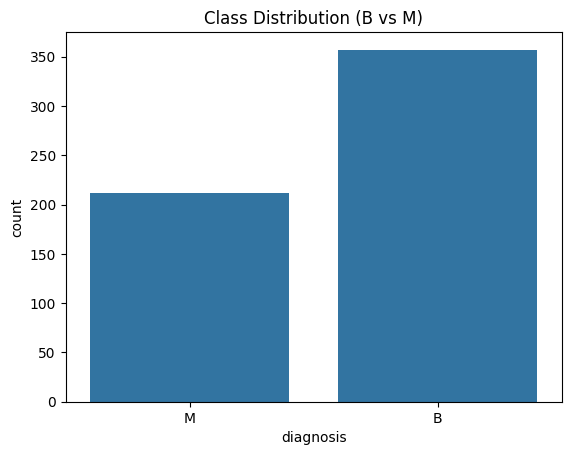

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم بياني بيوضح الفرق بين عدد عينات كل فئة
sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution (B vs M)')
plt.show()

In [5]:

model_weighted = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model_weighted.fit(X_train, y_train)

print("--- Evaluation: Class Weights ---")
print(classification_report(y_test, model_weighted.predict(X_test)))

--- Evaluation: Class Weights ---
              precision    recall  f1-score   support

           B       0.96      0.93      0.94       108
           M       0.88      0.94      0.91        63

    accuracy                           0.93       171
   macro avg       0.92      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171



In [11]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn

In [13]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42, k_neighbors=5) 
X_res, y_res = smote.fit_resample(X_train, y_train) 

# تدريب الموديل على البيانات الجديدة
model_smote = DecisionTreeClassifier(random_state=42)
model_smote.fit(X_res, y_res)

print("--- Evaluation: SMOTE ---")
print(classification_report(y_test, model_smote.predict(X_test)))

--- Evaluation: SMOTE ---
              precision    recall  f1-score   support

           B       0.97      0.95      0.96       108
           M       0.92      0.95      0.94        63

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



In [14]:
from imblearn.under_sampling import RandomUnderSampler


rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train) 

model_rus = DecisionTreeClassifier(random_state=42)
model_rus.fit(X_rus, y_rus)

print("--- Evaluation: Undersampling ---")
print(classification_report(y_test, model_rus.predict(X_test)))

--- Evaluation: Undersampling ---
              precision    recall  f1-score   support

           B       0.96      0.90      0.93       108
           M       0.84      0.94      0.89        63

    accuracy                           0.91       171
   macro avg       0.90      0.92      0.91       171
weighted avg       0.92      0.91      0.91       171

